# <center>随机梯度下降算法</center>

## 1. 问题描述

考虑最小化问题
$$
\min_{x\in\mathbb{R}^1} f(x) = \frac{1}{n} \sum_{i=1}^n f_i(x)
$$
其中 $n\geq 1$，$f_i(x) = (x-\omega_i)^2$，$\omega_i\sim N(\mu,\sigma^2)$ 为独立同分布的随机变量。给定初值 $x_0$ 和步长 $\eta>0$，比较下述迭代算法的结果。

#### 梯度下降算法（full-batch gradient descent）

$$
x_{k+1}^\text{GD} = x_{k}^\text{GD} - \frac{\eta}{n} \sum_{i=1}^n \nabla f_i(x_{k}^\text{GD})
$$

#### 随机梯度下降算法（mini-batch gradient descent）

$$
x_{k+1}^\text{SGD} = x_{k}^\text{SGD} - \frac{\eta}{m} \sum_{\gamma \in \mathcal{M}} \nabla f_\gamma(x_{k}^\text{SGD})\ \ \ \text{其中 $\mathcal{M}$ 代表随机抽取 $m$ 个样本所组成的下标集合}
$$

#### 时间平均策略（averaged stochastic gradient descent）

$$
x_{k+1}^\text{ASGD} = \frac{k}{k+1} x_{k}^\text{ASGD} + \frac{1}{k+1} x_{k}^\text{ASGD}
$$

## 2. 数据生成

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(666) # for reproducibility
# generate Gaussian sample points
smp_size = 1000;
smp_input = np.random.normal(loc=0, scale=2, size=(1, smp_size))

## 2-1. 梯度下降迭代算法（full-batch gradient descent）

In [2]:
def gradient_descent(x_ini, smp_input, step_size, max_ite):

    # initialization
    x_GD_path = []
    x_GD_old = x_ini
    
    # gradient descent iteration
    for index_ite in range(max_ite):
        
        # compute gradient
        fullbatch_grad = 2 * np.mean(x_GD_old - smp_input)        
        # update parameter
        x_GD_new = x_GD_old - step_size * fullbatch_grad     
        # append current value
        x_GD_path.append(x_GD_old)        
        # prepare for next iteration
        x_GD_old = x_GD_new
    
    return x_GD_path

## 2-2. 随机梯度下降迭代算法（mini-batch gradient descent）

In [3]:
def stochastic_gradient_descent(x_ini, smp_input, batch_size, step_size, max_ite):
    
    # initialization
    x_SGD_path = []
    x_SGD_old = x_ini
    
    # stochastic gradient descent iteration
    for index_ite in range(max_ite):
        
        # randomly select mini-batch
        smp_input = np.asarray(smp_input).flatten()
        batch_indices = np.random.choice(len(smp_input), size=batch_size, replace=False)
        batch_samples = smp_input[batch_indices]        
        # compute batch gradient
        minibatch_grad = 2 * np.mean(x_SGD_old - batch_samples)        
        # update parameter
        x_SGD_new = x_SGD_old - step_size * minibatch_grad
        # append current value
        x_SGD_path.append(x_SGD_old)
        
        # Prepare for next iteration
        x_SGD_old = x_SGD_new
    
    return x_SGD_path

## 2-3. 随机梯度下降法的时间平均策略（averaged mini-batch gradient descent）

In [4]:
def averaged_stochastic_gradient_descent(x_SGD_path, ite_ini, max_ite):

    # initialization
    x_ASGD_path = np.zeros_like(x_SGD_path)
    x_ASGD_path[ite_ini] = x_SGD_path[ite_ini]
    
    # apply Polyak averaging
    for i in range(ite_ini, max_ite_SGD):
        x_ASGD_path[i] = (i * x_ASGD_path[i-1] + x_SGD_path[i]) / (i + 1)

    return x_ASGD_path

## 2-4. 比较三种方法的迭代解（在相近的计算代价下）

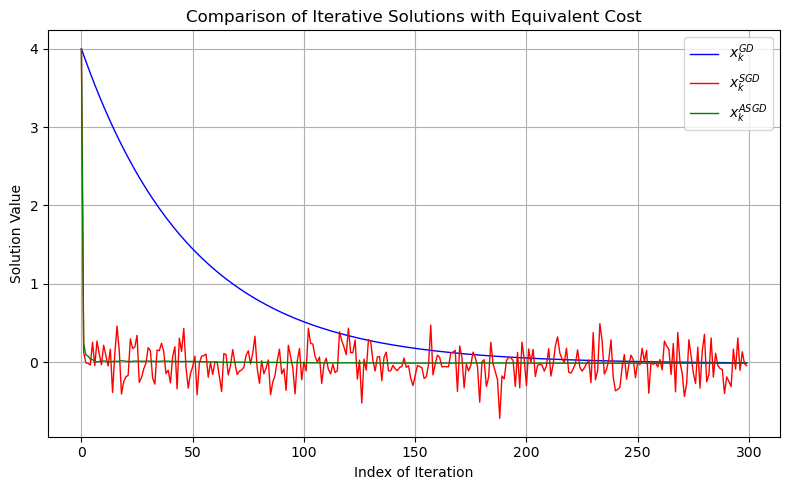

In [6]:
x_ini = 4;
step_size = 0.01;
max_ite_GD = 300;

batch_size = 1;
max_ite_SGD = max_ite_GD * (smp_size // batch_size)

x_GD_path = gradient_descent(x_ini, smp_input, step_size, max_ite_GD)
x_SGD_path = stochastic_gradient_descent(x_ini, smp_input, batch_size, step_size, max_ite_SGD)
x_ASGD_path = averaged_stochastic_gradient_descent(x_SGD_path, 0, max_ite_SGD)

# plot iterative solutions
plt.figure(figsize=(8, 5))
plt.plot(x_GD_path, 'b-', linewidth=1, label=r'$x_k^{GD}$')
plt.plot(x_SGD_path[::smp_size], 'r-', linewidth=1, label=r'$x_k^{SGD}$')
plt.plot(x_ASGD_path[::smp_size], 'g-', linewidth=1, label=r'$x_k^{ASGD}$')
plt.xlabel('Index of Iteration')
plt.ylabel('Solution Value')
plt.title('Comparison of Iterative Solutions with Equivalent Cost')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()